# Gemma sensitivity investigation

After fixing a previous problem with the Fisher information estimation for Gemma, there remains an issue where the per-tensor-perturbation KL test does not agree with predicted KL.

We investigate this, identifying early layers as the source of the problem, and ruling out `bfloat16` precision issues.

In [4]:
import matplotlib
import pandas as pd
import re
import seaborn as sns
from torch import tensor
from typing import Any

import weight_formats.experiments as E

matplotlib.rcParams.update({"axes.spines.top": False, "axes.spines.right": False, "legend.frameon": False})

In [9]:
fisher = {k: E.fisher.fetch_fisher_sum(k, "20250604-fisher") for k in ["google/gemma-3-1b-pt", "google/gemma-3-4b-pt"]}
fisher_float32 = {k: E.fisher.fetch_fisher_sum(k, "20251119-gemma-fisher-float32") for k in ["google/gemma-3-1b-pt", "google/gemma-3-4b-pt"]}

def load_run(run: E.AttrDict) -> dict[str, Any] | None:
    c = run.config
    s = run.summary
    if "kl_div" not in s:
        return None
    return {
        "model": c.model,
        "parameter": c.test.parameter,
        "scale": c.test.scale,
        "rm2": s.rms,
        "dtype": c.get("dtype") or "default",
        "kl_div": tensor(s.kl_div).mean().item(),
        "fisher_sum": fisher[c.model][c.test.parameter],
        "fisher_float32_sum": fisher_float32[c.model][c.test.parameter],
    }

def layer_index(s: str) -> int | None:
    m = re.search(r"\.(\d+)\.", s)
    if m:
        return int(m.group(1))

runs = E.runs("20251119-gemma-sensitivity")
df = pd.DataFrame(filter(None, [load_run(run) for run in runs]))
df[f"kl_div_prediction"] = 0.5 * (df.scale * df.rm2) ** 2 * df.fisher_sum
df[f"kl_div_prediction_float32"] = 0.5 * (df.scale * df.rm2) ** 2 * df.fisher_float32_sum
df["layer_index"] = df.parameter.apply(layer_index)
df.head()

,model,parameter,scale,rm2,dtype,kl_div,fisher_sum,fisher_float32_sum,kl_div_prediction,kl_div_prediction_float32,layer_index
0,google/gemma-3-4b-pt,language_model.model.embed_tokens.weight,0.25,0.019219,float32,0.103277,15295.90900,58918.15600,0.176552,0.680058,NaN
1,google/gemma-3-4b-pt,language_model.model.layers.0.self_attn.q_proj...,0.25,0.014823,float32,0.000230,456.05228,3779.62770,0.003131,0.025952,0.0
2,google/gemma-3-4b-pt,language_model.model.layers.0.self_attn.k_proj...,0.25,0.026353,float32,0.000225,547.20459,7255.87790,0.011875,0.157467,0.0
3,google/gemma-3-4b-pt,language_model.model.layers.0.self_attn.v_proj...,0.25,0.026353,float32,0.000385,157.70656,884.21277,0.003423,0.019189,0.0
4,google/gemma-3-4b-pt,language_model.model.layers.0.self_attn.o_proj...,0.25,0.019653,float32,0.000561,817.20312,4480.41850,0.009864,0.054080,0.0


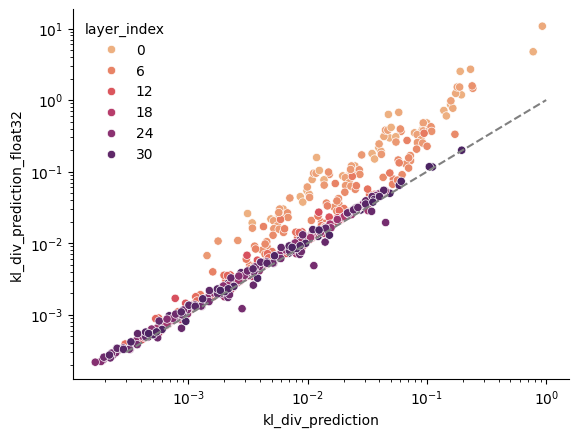

In [12]:
ax = sns.scatterplot(data=df[df.model == "google/gemma-3-4b-pt"], y="kl_div_prediction_float32", x="kl_div_prediction", hue="layer_index", palette="flare")
ax.set_xscale("log")
ax.set_yscale("log")
xs = [3e-4, 1]
ax.plot(xs, xs, ls="--", color="gray")

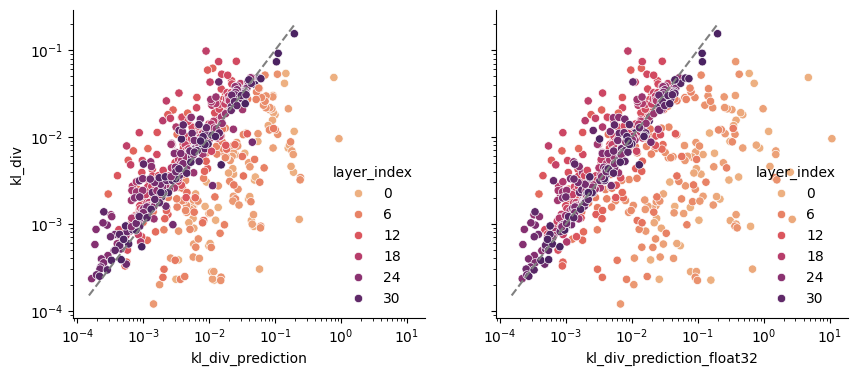

In [17]:
_, axs = matplotlib.pyplot.subplots(1, 2, figsize=(10, 4), sharey=True, sharex=True)
sns.scatterplot(data=df[df.model == "google/gemma-3-4b-pt"], y="kl_div", x="kl_div_prediction", hue="layer_index", palette="flare", ax=axs[0])
sns.scatterplot(data=df[df.model == "google/gemma-3-4b-pt"], y="kl_div", x="kl_div_prediction_float32", hue="layer_index", palette="flare", ax=axs[1])
for ax in axs:
    ax.set_xscale("log")
    ax.set_yscale("log")
    xs = [1.5e-4, 2e-1]
    ax.plot(xs, xs, ls="--", color="gray")